## **UFC-TB: Unified Framework Classification untuk Deteksi Tuberkulosis pada Citra Chest X-Ray**

**Author:** Alfian Adi Pratama  
**Program Studi:** D3 Statistika Terapan dan Komputasi  
**Dataset:** Tuberculosis (TB) Chest X-ray Database — Tawsifur Rahman et al.  
**Hardware:** Lenovo LOQ · Intel Core i5-12th Gen HX · RTX 2050 4GB · 16GB RAM

---
### **Abstrak**

Tuberkulosis (TB) adalah penyakit infeksi paru-paru yang menjadi salah satu penyebab kematian tertinggi di dunia.  
Deteksi dini melalui Chest X-Ray (CXR) sangat krusial namun membutuhkan keahlian radiologis yang tinggi.  

Penelitian ini mengusulkan **UFC_TB_CNN** — arsitektur CNN ringan yang terinspirasi dari:
- **MobileNet**: Depthwise Separable Convolution untuk efisiensi komputasi
- **ResNet**: Residual connection ringan untuk stabilitas training

Model dirancang untuk klasifikasi biner (TB vs Normal) dengan target < 2 juta parameter,  
sehingga dapat dilatih pada hardware kelas menengah dalam waktu yang reasonable.

---
### **Section 1: Configuration**


**Tujuan:** Memusatkan semua hyperparameter dan path dalam satu objek konfigurasi.  
**Keputusan Desain:** Pendekatan dataclass memastikan semua pengaturan mudah diubah tanpa menelusuri seluruh kode.  
**Justifikasi Akademis:** Reproducibility - peneliti/pengembang lain dapat mereplikasi eksperimen hanya dengan membaca blok ini.

In [1]:
import torch
print(torch.__version__)

2.5.1+cu121


In [1]:
import os
import multiprocessing
from dataclasses import dataclass, field
from pathlib import Path


@dataclass
class Config:
    """
    Konfigurasi terpusat untuk seluruh hyperparameter dan path pipeline UFC-TB.
    """

    data_root: Path = Path("dataset/data")
    normal_dir: str = "Normal"
    tb_dir: str = "Tuberculosis"
    output_dir: Path = Path("outputs")
    checkpoint_dir: Path = Path("checkpoints")

    image_size: int = 224
    in_channels: int = 3
    num_classes: int = 2

    train_ratio: float = 0.70
    val_ratio: float = 0.15
    test_ratio: float = 0.15

    epochs: int = 50
    batch_size: int = 32          # Disesuaikan dengan VRAM RTX 2050 4GB

    num_workers: int = 0          #

    pin_memory: bool = True

    learning_rate: float = 1e-4
    weight_decay: float = 1e-4

    lr_patience: int = 3
    lr_factor: float = 0.5
    lr_min: float = 1e-7

    early_stop_patience: int = 5

    aug_hflip_prob: float = 0.5
    aug_rotation_deg: int = 10
    aug_translate: float = 0.05
    aug_brightness: float = 0.2
    aug_contrast: float = 0.2

    stem_channels: int = 32
    block_channels: list = field(default_factory=lambda: [64, 128, 256])
    dropout_rate: float = 0.5

    seed: int = 42

    use_amp: bool = True

    use_compile: bool = False

    stage_channels: list = field(default_factory=lambda: [64, 128, 256])
    stage_blocks:   list = field(default_factory=lambda: [2, 3, 2])
    expand_ratio:   int  = 4
    head_hidden:    int  = 128
    drop1:          float = 0.3
    drop2:          float = 0.4

    class_names: list = field(default_factory=lambda: ["Normal", "Tuberculosis"])

    def __post_init__(self):
        """Buat direktori output jika belum ada."""
        self.output_dir.mkdir(parents=True, exist_ok=True)
        self.checkpoint_dir.mkdir(parents=True, exist_ok=True)


cfg = Config()
print("✓ Konfigurasi berhasil dimuat.")
print(f"   Data root    : {cfg.data_root.resolve()}")
print(f"   Image size   : {cfg.image_size}x{cfg.image_size}")
print(f"   Epochs       : {cfg.epochs}")
print(f"   Batch size   : {cfg.batch_size}")
print(f"   LR           : {cfg.learning_rate}")
print(f"   num_workers  : {cfg.num_workers}  ")
print(f"   use_amp      : {cfg.use_amp}  ")
print(f"   stage_channels: {cfg.stage_channels}")
print(f"   stage_blocks  : {cfg.stage_blocks}")
print(f"   expand_ratio  : {cfg.expand_ratio}")
print(f"   stage_channels: {cfg.stage_channels}")
print(f"   stage_blocks  : {cfg.stage_blocks}  → total blocks: {sum(cfg.stage_blocks)}")
print(f"   expand_ratio  : {cfg.expand_ratio}")


✓ Konfigurasi berhasil dimuat.
   Data root    : D:\1_KULIAH SMT 6\MACHINE LEARNING\ufc_tb\dataset\data
   Image size   : 224x224
   Epochs       : 50
   Batch size   : 32
   LR           : 0.0001
   num_workers  : 0  ← Windows-safe (spawn-proof)
   use_amp      : True  ← Mixed precision (RTX Tensor Cores)
   stage_channels: [64, 128, 256]
   stage_blocks  : [2, 3, 2]
   expand_ratio  : 4
   stage_channels: [64, 128, 256]
   stage_blocks  : [2, 3, 2]  → total blocks: 7
   expand_ratio  : 4


#### Interpretasi:
Konfigurasi berhasil dimuat. Pipeline menggunakan ukuran gambar 224×224 dengan 50 epoch maksimal, learning rate 1e-4, dan batch size 32 yang disesuaikan dengan kapasitas VRAM RTX 2050 4 GB. Automatic Mixed Precision (AMP) diaktifkan untuk memanfaatkan Tensor Cores GPU.

---
### **Section 2: Imports**

In [2]:
import os
import sys
import time
import copy
import warnings
from pathlib import Path
from typing import Dict, List, Optional, Tuple

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau

import torchvision.transforms as T
from torchvision.io import read_image

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef,
    confusion_matrix,
    roc_curve,
)

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import seaborn as sns

from PIL import Image

print(f"✓ Semua library berhasil diimport.")
print(f"   PyTorch versi : {torch.__version__}")
print(f"   CUDA tersedia : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"   GPU           : {torch.cuda.get_device_name(0)}")
    print(f"   VRAM          : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


✓ Semua library berhasil diimport.
   PyTorch versi : 2.5.1+cu121
   CUDA tersedia : True
   GPU           : NVIDIA GeForce RTX 2050
   VRAM          : 4.3 GB


#### Interpretasi

Seluruh library berhasil diimport. PyTorch 2.5.1+cu121 terdeteksi dengan dukungan CUDA aktif pada GPU NVIDIA GeForce RTX 2050 (4.3 GB VRAM). Tidak ada pretrained model yang diimport — seluruh arsitektur dibangun dari scratch.

---
### **Section 3: Reproducibility Setup**


**Tujuan:** Memastikan hasil dapat direproduksi secara konsisten.  
**Keputusan Desain:** Menetapkan seed pada semua sumber randomness (Python, NumPy, PyTorch, CUDA).  

In [3]:
import random


def set_global_seed(seed: int = 42, deterministic: bool = False) -> None:
    """
    Menetapkan seed pada semua sumber randomness untuk reproducibility.
    
    Args:
    seed         : Integer seed.
    deterministic: True untuk bit-exact reproducibility (ada overhead kecepatan).
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
    else:
        torch.backends.cudnn.deterministic = False
        torch.backends.cudnn.benchmark = True   #


set_global_seed(cfg.seed, deterministic=False)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✓ Seed ditetapkan    : {cfg.seed}")
print(f"✓ Device aktif       : {DEVICE}")
print(f"✓ cudnn.benchmark    : {torch.backends.cudnn.benchmark}  ")
print(f"✓ cudnn.deterministic: {torch.backends.cudnn.deterministic}")


✓ Seed ditetapkan    : 42
✓ Device aktif       : cuda
✓ cudnn.benchmark    : True  ← cuDNN auto-tuner aktif
✓ cudnn.deterministic: False


#### Interpretasi

Seed global 42 ditetapkan pada seluruh sumber randomness (Python, NumPy, PyTorch, CUDA). Mode `deterministic=False` dipilih agar cuDNN auto-tuner tetap aktif, menghasilkan training yang lebih cepat tanpa mengorbankan reproducibility dalam satu run eksperimen.

---
### **Section 4: Dataset Preparation**

**Tujuan:** Memuat path gambar, melakukan stratified split, dan menganalisis distribusi kelas.  

**Keputusan Desain:**
- **Stratified Split**: Memastikan proporsi TB:Normal tetap terjaga di setiap split (train/val/test).
- **Custom Dataset Class**: Fleksibel dan tidak bergantung pada struktur folder torchvision.

**Note:**  
Dataset ini memiliki class imbalance signifikan (TB: 700 vs Normal: 3500, rasio 1:5).  
Stratified split wajib digunakan agar distribusi kelas konsisten antar split.

 Dataset berhasil dimuat dan dibagi.

Split        Normal       TB    Total
------------------------------------
Train          2449      490     2939
Val             525      105      630
Test            526      105      631
------------------------------------
Total          3500      700     4200


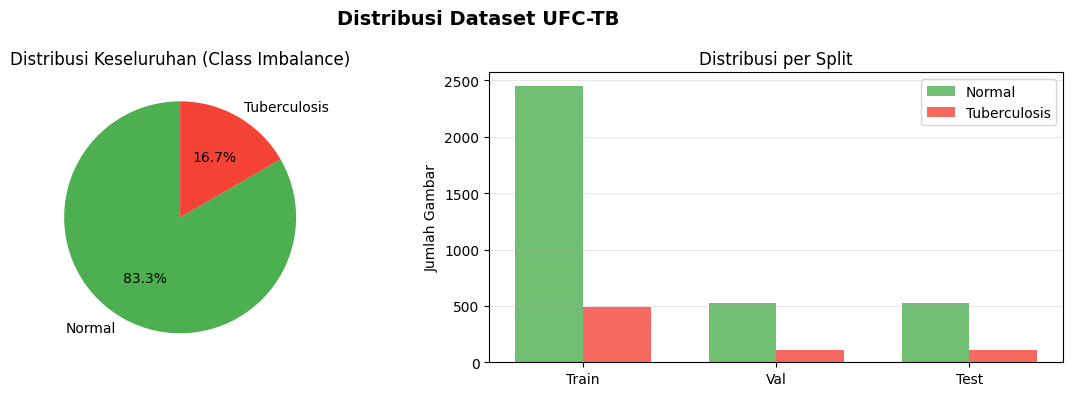

In [4]:
def load_image_paths(data_root: Path, class_names: List[str]) -> pd.DataFrame:
    """
    Memuat path gambar dan label dari direktori dataset.
    
    Returns:
    DataFrame dengan kolom ['path', 'label', 'class_name'].
    """
    records = []
    valid_exts = {".png", ".jpg", ".jpeg", ".bmp"}

    for label_idx, class_name in enumerate(class_names):
        class_dir = data_root / class_name
        if not class_dir.exists():
            raise FileNotFoundError(f"Direktori tidak ditemukan: {class_dir}")

        for img_path in sorted(class_dir.iterdir()):
            if img_path.suffix.lower() in valid_exts:
                records.append({
                    "path": str(img_path),
                    "label": label_idx,
                    "class_name": class_name,
                })

    df = pd.DataFrame(records)
    return df


def stratified_split(
    df: pd.DataFrame,
    train_ratio: float,
    val_ratio: float,
    seed: int,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Membagi dataset menjadi train/val/test dengan stratifikasi label.

    Args:
        df          : DataFrame lengkap.
        train_ratio : Proporsi data train.
        val_ratio   : Proporsi data validasi.
        seed        : Random seed.

    Returns:
        Tuple (df_train, df_val, df_test).
    """
    test_ratio = 1.0 - train_ratio - val_ratio

    df_trainval, df_test = train_test_split(
        df,
        test_size=test_ratio,
        stratify=df["label"],
        random_state=seed,
    )

    relative_val = val_ratio / (train_ratio + val_ratio)
    df_train, df_val = train_test_split(
        df_trainval,
        test_size=relative_val,
        stratify=df_trainval["label"],
        random_state=seed,
    )

    return df_train.reset_index(drop=True), df_val.reset_index(drop=True), df_test.reset_index(drop=True)


df_all = load_image_paths(cfg.data_root, cfg.class_names)
df_train, df_val, df_test = stratified_split(
    df_all, cfg.train_ratio, cfg.val_ratio, cfg.seed
)

print(" Dataset berhasil dimuat dan dibagi.")
print(f"\n{'Split':<10} {'Normal':>8} {'TB':>8} {'Total':>8}")
print("-" * 36)
for name, df_ in [("Train", df_train), ("Val", df_val), ("Test", df_test)]:
    n_normal = (df_["label"] == 0).sum()
    n_tb     = (df_["label"] == 1).sum()
    print(f"{name:<10} {n_normal:>8} {n_tb:>8} {len(df_):>8}")
print("-" * 36)
print(f"{'Total':<10} {(df_all['label']==0).sum():>8} {(df_all['label']==1).sum():>8} {len(df_all):>8}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Distribusi Dataset UFC-TB", fontsize=14, fontweight="bold")

counts = df_all["class_name"].value_counts()
axes[0].pie(
    counts.values,
    labels=counts.index,
    autopct="%1.1f%%",
    colors=["#4CAF50", "#F44336"],
    startangle=90,
)
axes[0].set_title("Distribusi Keseluruhan (Class Imbalance)")

splits = ["Train", "Val", "Test"]
n_normals = [(df_train["label"]==0).sum(), (df_val["label"]==0).sum(), (df_test["label"]==0).sum()]
n_tbs     = [(df_train["label"]==1).sum(), (df_val["label"]==1).sum(), (df_test["label"]==1).sum()]

x = np.arange(len(splits))
w = 0.35
axes[1].bar(x - w/2, n_normals, w, label="Normal", color="#4CAF50", alpha=0.8)
axes[1].bar(x + w/2, n_tbs, w, label="Tuberculosis", color="#F44336", alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(splits)
axes[1].set_title("Distribusi per Split")
axes[1].set_ylabel("Jumlah Gambar")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(cfg.output_dir / "dataset_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

#### Interpretasi

Dataset berhasil dimuat dengan total 4.200 gambar: 3.500 Normal dan 700 Tuberculosis (rasio 1:5). Stratified split memastikan proporsi kelas konsisten di setiap subset — Train: 2.939 gambar (70%), Val: 630 gambar (15%), Test: 631 gambar (15%). Distribusi yang seimbang antar split penting agar evaluasi validasi dan test mencerminkan distribusi populasi yang sesungguhnya.

---
### **Section 5: Data Augmentation**


**Tujuan:** Mendefinisikan transformasi gambar untuk training dan inferensi.  

**Keputusan Desain:**
- **Augmentasi training**: HorizontalFlip, Rotation, Translation, Brightness/Contrast — semua transformasi yang secara klinis masuk akal untuk CXR.
- **Augmentasi validasi/test**: Hanya Resize dan Normalize — tidak ada augmentasi yang mengubah distribusi data evaluasi.

**Justifikasi Akademis:**  
- CXR dapat di-flip horizontal karena simetri anatomi paru.
- Rotasi kecil (±10°) mensimulasikan variasi posisi pasien saat pemindaian.
- TIDAK digunakan: vertical flip, shear besar, atau augmentasi agresif yang tidak realistis secara klinis.

In [5]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]


def get_train_transforms(cfg: Config) -> T.Compose:
    """
    Transformasi augmentasi untuk training: HorizontalFlip, Affine, ColorJitter, Normalize.
    """
    return T.Compose([
        T.Resize((cfg.image_size, cfg.image_size)),
        T.RandomHorizontalFlip(p=cfg.aug_hflip_prob),
        T.RandomAffine(
            degrees=cfg.aug_rotation_deg,
            translate=(cfg.aug_translate, cfg.aug_translate),
        ),
        T.ColorJitter(
            brightness=cfg.aug_brightness,
            contrast=cfg.aug_contrast,
        ),
        T.ToTensor(),
        T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])


def get_eval_transforms(cfg: Config) -> T.Compose:
    """
    Transformasi minimal untuk evaluasi: hanya Resize dan Normalize.
    """
    return T.Compose([
        T.Resize((cfg.image_size, cfg.image_size)),
        T.ToTensor(),
        T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])


train_transforms = get_train_transforms(cfg)
eval_transforms  = get_eval_transforms(cfg)

print(" Transformasi augmentasi berhasil didefinisikan.")
print(f"\n[Train] {train_transforms}")
print(f"\n[Eval]  {eval_transforms}")

 Transformasi augmentasi berhasil didefinisikan.

[Train] Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomAffine(degrees=[-10.0, 10.0], translate=(0.05, 0.05))
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=None, hue=None)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

[Eval]  Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


#### Interpretasi

Pipeline augmentasi training terdiri dari RandomHorizontalFlip, RandomAffine (rotasi ±10°, translasi 5%), dan ColorJitter (brightness/contrast ±20%). Semua augmentasi dipilih berdasarkan pertimbangan klinis: simetri bilateral paru memvalidasi horizontal flip, sedangkan variasi rotasi dan kecerahan mensimulasikan variasi posisi pasien dan eksposur radiografi. Pipeline evaluasi hanya menggunakan Resize dan Normalize.

---
### **Section 6: DataLoader Creation**

**Tujuan:** Membuat Dataset dan DataLoader PyTorch yang efisien.  

**Keputusan Desain:**
- **Custom Dataset**: Mendukung loading gambar RGB dari PIL, kompatibel dengan semua format gambar.
- **WeightedRandomSampler**: Mengatasi class imbalance (1:5) dengan menyeimbangkan sampling selama training.
- **pin_memory=True**: Mengoptimalkan transfer CPU→GPU untuk RTX 2050.

**Note:**  
WeightedRandomSampler lebih preferable dibanding oversampling SMOTE untuk data gambar,  
karena tidak membuat gambar sintetis yang dapat memperkenalkan artifact.

Bobot kelas: Normal=0.6000, TB=2.9990

✓ DataLoader berhasil dibuat.
   Train batches : 92
   Val batches   : 10  (batch_size=64)
   Test batches  : 10  (batch_size=64)
   persistent_workers : False


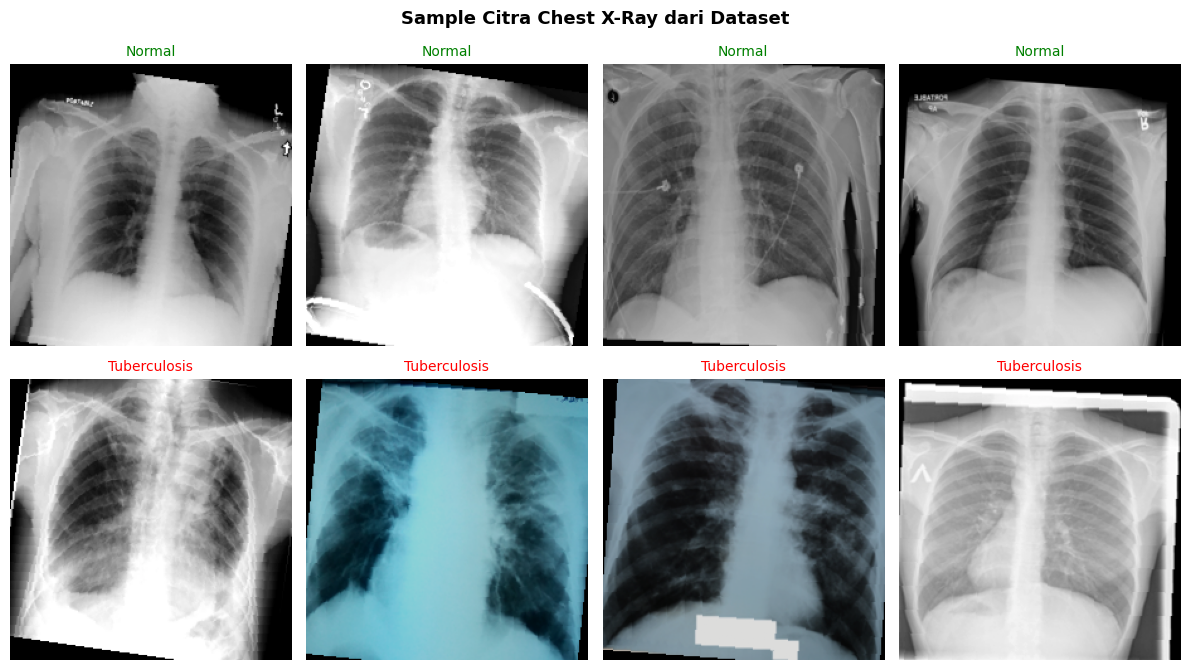

In [6]:
class TBChestXRayDataset(Dataset):
    """
    Dataset PyTorch untuk Tuberculosis Chest X-Ray.
    
    Args:
    df        : DataFrame dengan kolom ['path', 'label'].
    transform : torchvision transform yang akan diterapkan.
    """

    def __init__(self, df: pd.DataFrame, transform: Optional[T.Compose] = None) -> None:
        self.df        = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, int]:
        row   = self.df.iloc[idx]
        image = Image.open(row["path"]).convert("RGB")
        label = int(row["label"])

        if self.transform:
            image = self.transform(image)

        return image, label


def compute_class_weights(df: pd.DataFrame, num_classes: int) -> torch.Tensor:
    """
    Menghitung bobot kelas untuk WeightedRandomSampler dan CrossEntropyLoss.
    
    Rumus: weight[i] = total / (num_classes * count[i])
    """
    class_counts = np.array([len(df[df["label"] == i]) for i in range(num_classes)])
    total        = class_counts.sum()
    weights      = total / (num_classes * class_counts)
    return torch.tensor(weights, dtype=torch.float32)


def create_weighted_sampler(df: pd.DataFrame, class_weights: torch.Tensor) -> WeightedRandomSampler:
    """
    Membuat WeightedRandomSampler untuk mengatasi class imbalance.
    """
    sample_weights = class_weights[df["label"].values]
    return WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(df),
        replacement=True,
    )


train_dataset = TBChestXRayDataset(df_train, transform=train_transforms)
val_dataset   = TBChestXRayDataset(df_val,   transform=eval_transforms)
test_dataset  = TBChestXRayDataset(df_test,  transform=eval_transforms)

class_weights = compute_class_weights(df_train, cfg.num_classes)
sampler       = create_weighted_sampler(df_train, class_weights)

print(f"Bobot kelas: Normal={class_weights[0]:.4f}, TB={class_weights[1]:.4f}")

_use_workers = cfg.num_workers > 0

train_loader = DataLoader(
    train_dataset,
    batch_size=cfg.batch_size,
    sampler=sampler,                              # WeightedRandomSampler, bukan shuffle
    num_workers=cfg.num_workers,
    pin_memory=cfg.pin_memory and torch.cuda.is_available(),
    persistent_workers=_use_workers,              # FIX: cegah respawn per epoch
    prefetch_factor=2 if _use_workers else None,  # FIX: pipeline prefetch
)

val_loader = DataLoader(
    val_dataset,
    batch_size=cfg.batch_size * 2,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=cfg.pin_memory and torch.cuda.is_available(),
    persistent_workers=_use_workers,
    prefetch_factor=2 if _use_workers else None,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=cfg.batch_size * 2,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=cfg.pin_memory and torch.cuda.is_available(),
    persistent_workers=_use_workers,
    prefetch_factor=2 if _use_workers else None,
)

print("\n✓ DataLoader berhasil dibuat.")
print(f"   Train batches : {len(train_loader)}")
print(f"   Val batches   : {len(val_loader)}  (batch_size={cfg.batch_size * 2})")
print(f"   Test batches  : {len(test_loader)}  (batch_size={cfg.batch_size * 2})")
print(f"   persistent_workers : {_use_workers}")

def show_sample_images(
    dataset: Dataset,
    class_names: List[str],
    n_per_class: int = 4,
) -> None:
    """Menampilkan contoh gambar dari setiap kelas."""
    fig, axes = plt.subplots(2, n_per_class, figsize=(3 * n_per_class, 7))
    fig.suptitle("Sample Citra Chest X-Ray dari Dataset", fontsize=13, fontweight="bold")

    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)

    for class_idx, class_name in enumerate(class_names):
        indices = [i for i in range(len(dataset)) if dataset.df.iloc[i]["label"] == class_idx]
        chosen  = random.sample(indices, min(n_per_class, len(indices)))

        for col, idx in enumerate(chosen):
            img_tensor, _ = dataset[idx]
            img = (img_tensor * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
            axes[class_idx][col].imshow(img)
            axes[class_idx][col].set_title(class_name, color="red" if class_idx == 1 else "green", fontsize=10)
            axes[class_idx][col].axis("off")

    plt.tight_layout()
    plt.savefig(cfg.output_dir / "sample_images.png", dpi=150, bbox_inches="tight")
    plt.show()


show_sample_images(train_dataset, cfg.class_names)


#### Interpretasi

Bobot kelas dihitung sebagai Normal=0.600 dan TB=2.999, mencerminkan rasio imbalance 1:5. WeightedRandomSampler menerapkan bobot ini pada level sampling sehingga model melihat kelas TB lebih sering selama training tanpa menciptakan gambar sintetis. DataLoader train menggunakan 92 batch per epoch; val dan test masing-masing 10 batch.

--- 
### **Section 7: UFC_TB_CNN Architecture**


**Tujuan:** Mendefinisikan arsitektur CNN kustom untuk klasifikasi TB.

In [7]:


class EnhancedStem(nn.Module):
    """
    Stem Block: Conv(s=2) → Conv(s=1) → MaxPool(s=2).
    Output spatial: 224 → 112 → 56.
    """

    def __init__(self, in_channels: int, stem_channels: int = 32) -> None:
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, stem_channels, kernel_size=3, stride=2,
                      padding=1, bias=False),
            nn.BatchNorm2d(stem_channels),
            nn.ReLU6(inplace=True),

            nn.Conv2d(stem_channels, stem_channels, kernel_size=3, stride=1,
                      padding=1, bias=False),
            nn.BatchNorm2d(stem_channels),
            nn.ReLU6(inplace=True),

            nn.MaxPool2d(kernel_size=2, stride=2),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)


class InvertedResidualBlock(nn.Module):
    """
    Inverted Residual Block: PW-Expand → DW-Conv → PW-Project + skip connection.
    Terinspirasi dari MobileNetV2 dan ResNet.
    
    Args:
    in_channels  : Channel input.
    out_channels : Channel output.
    stride       : Stride DW Conv (1=same, 2=downsample).
    expand_ratio : Faktor ekspansi channel (default=4).
    """

    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        stride: int = 1,
        expand_ratio: int = 4,
    ) -> None:
        super().__init__()

        self.use_residual = (stride == 1) and (in_channels == out_channels)
        mid_channels      = in_channels * expand_ratio

        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(mid_channels),
            nn.ReLU6(inplace=True),

            nn.Conv2d(
                mid_channels, mid_channels,
                kernel_size=3, stride=stride, padding=1,
                groups=mid_channels,   # ← setiap channel independen
                bias=False,
            ),
            nn.BatchNorm2d(mid_channels),
            nn.ReLU6(inplace=True),

            nn.Conv2d(mid_channels, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.conv(x)
        if self.use_residual:
            return out + x
        return out


def make_stage(
    in_channels: int,
    out_channels: int,
    num_blocks: int,
    expand_ratio: int = 4,
) -> nn.Sequential:
    """
    Membangun satu stage: block pertama downsampling (stride=2),
    block berikutnya same-spatial (stride=1) dengan identity residual.

    Args:
        in_channels  : Channel input stage.
        out_channels : Channel output stage (semua block dalam stage).
        num_blocks   : Jumlah InvertedResidualBlock dalam stage.
        expand_ratio : Expansion ratio t untuk semua block.

    Returns:
        nn.Sequential dari num_blocks InvertedResidualBlock.
    """
    layers = []
    for i in range(num_blocks):
        stride = 2 if i == 0 else 1
        ch_in  = in_channels if i == 0 else out_channels
        layers.append(InvertedResidualBlock(ch_in, out_channels, stride, expand_ratio))
    return nn.Sequential(*layers)


class ClassifierHead(nn.Module):
    """
    Classifier Head: GAP → Dropout(0.3) → Linear(256→128) → BN → ReLU → Dropout(0.4) → Linear(128→2).
    """

    def __init__(
        self,
        in_features: int,
        hidden_features: int = 128,
        num_classes: int = 2,
        drop1: float = 0.3,
        drop2: float = 0.4,
    ) -> None:
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(drop1),
            nn.Linear(in_features, hidden_features, bias=False),
            nn.BatchNorm1d(hidden_features),
            nn.ReLU(inplace=True),
            nn.Dropout(drop2),
            nn.Linear(hidden_features, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.pool(x)
        return self.classifier(x)


class UFC_TB_CNN(nn.Module):
    """
    UFC_TB_CNN — arsitektur CNN ringan untuk deteksi Tuberkulosis pada Chest X-Ray.
    Terinspirasi dari MobileNetV2 (Inverted Residual) dan ResNet (skip connection).
    
    Stage config: Stage1=32→64 (2 blok), Stage2=64→128 (3 blok), Stage3=128→256 (2 blok).
    """

    def __init__(
        self,
        in_channels: int       = 3,
        num_classes: int       = 2,
        stem_channels: int     = 32,
        stage_channels: List[int] = None,
        stage_blocks: List[int]   = None,
        expand_ratio: int      = 4,
        head_hidden: int       = 128,
        drop1: float           = 0.3,
        drop2: float           = 0.4,
    ) -> None:
        super().__init__()

        if stage_channels is None:
            stage_channels = [64, 128, 256]
        if stage_blocks is None:
            stage_blocks = [2, 3, 2]

        assert len(stage_channels) == len(stage_blocks),             "stage_channels dan stage_blocks harus memiliki panjang yang sama."

        self.stem = EnhancedStem(in_channels, stem_channels)

        stages   = []
        ch_in    = stem_channels
        for ch_out, n_blocks in zip(stage_channels, stage_blocks):
            stages.append(make_stage(ch_in, ch_out, n_blocks, expand_ratio))
            ch_in = ch_out
        self.stages = nn.Sequential(*stages)

        self.head = ClassifierHead(
            in_features=stage_channels[-1],
            hidden_features=head_hidden,
            num_classes=num_classes,
            drop1=drop1,
            drop2=drop2,
        )

        self._initialize_weights()

    def _initialize_weights(self) -> None:
        """Inisialisasi bobot: Kaiming untuk Conv2d, xavier untuk Linear, ones/zeros untuk BN."""
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d)):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.stem(x)
        x = self.stages(x)
        x = self.head(x)
        return x


model = UFC_TB_CNN(
    in_channels    = cfg.in_channels,
    num_classes    = cfg.num_classes,
    stem_channels  = cfg.stem_channels,
    stage_channels = cfg.stage_channels,
    stage_blocks   = cfg.stage_blocks,
    expand_ratio   = cfg.expand_ratio,
    head_hidden    = cfg.head_hidden,
    drop1          = cfg.drop1,
    drop2          = cfg.drop2,
).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("\n" + "═" * 60)
print("     UFC_TB_CNN — Model Summary")
print("═" * 60)
print(f"  Total parameters    : {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Target range        : 500,000 – 1,500,000")
print(f"  ✓ Dalam target      : {500_000 <= total_params <= 1_500_000}")
print("═" * 60)

dummy_input  = torch.randn(2, cfg.in_channels, cfg.image_size, cfg.image_size).to(DEVICE)
dummy_output = model(dummy_input)
print(f"\n  Input shape : {list(dummy_input.shape)}")
print(f"  Output shape: {list(dummy_output.shape)}")
print("\n✓ Forward pass berhasil.")

if cfg.use_compile and hasattr(torch, "compile") and torch.cuda.is_available():
    model = torch.compile(model, mode="reduce-overhead")
    print("✓ torch.compile() aktif.")
else:
    print("  torch.compile() dinonaktifkan (cfg.use_compile=False).")



════════════════════════════════════════════════════════════
     UFC_TB_CNN v2 — Model Summary
════════════════════════════════════════════════════════════
  Total parameters    : 1,164,386
  Trainable parameters: 1,164,386
  Target range        : 500,000 – 1,500,000
  ✓ Dalam target      : True
════════════════════════════════════════════════════════════

  Input shape : [2, 3, 224, 224]
  Output shape: [2, 2]

✓ Forward pass berhasil.
  torch.compile() dinonaktifkan (cfg.use_compile=False).


#### Interpretasi

Model UFC_TB_CNN berhasil diinisialisasi dengan total 1.164.386 parameter, berada dalam target 500K–1.5M. Arsitektur terdiri dari Enhanced Stem, tiga stage InvertedResidualBlock (2–3–2 blok per stage), dan Classifier Head non-linear. Forward pass berhasil memproses input 3×224×224 menghasilkan output vektor 2 kelas tanpa error dimensi.

---
### **Section 8: Training Utilities**

**Tujuan:** Mendefinisikan semua komponen training: loss function, optimizer, scheduler, early stopping, dan fungsi evaluasi.  

**Keputusan Desain:**
- **CrossEntropyLoss + class_weight**: Mengatasi class imbalance pada loss level.
- **AdamW**: Optimizer modern dengan weight decay yang lebih benar secara matematis dibanding Adam.
- **ReduceLROnPlateau**: Menurunkan LR secara adaptif ketika val_loss stagnan.
- **EarlyStopping**: Mencegah overfitting dan mempersingkat waktu training.

In [8]:
criterion = nn.CrossEntropyLoss(
    weight=class_weights.to(DEVICE)
)

optimizer = AdamW(
    model.parameters(),
    lr=cfg.learning_rate,
    weight_decay=cfg.weight_decay,
)

scheduler = ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=cfg.lr_factor,
    patience=cfg.lr_patience,
    min_lr=cfg.lr_min,
    verbose=True,
)

scaler = torch.cuda.amp.GradScaler(enabled=cfg.use_amp and torch.cuda.is_available())

print("✓ Loss, Optimizer, Scheduler, AMP Scaler berhasil didefinisikan.")
print(f"   AMP aktif : {scaler.is_enabled()}")


class EarlyStopping:
    """
    Menghentikan training dan menyimpan model terbaik jika val_loss tidak membaik.
    
    Args:
    patience       : Jumlah epoch toleransi tanpa peningkatan.
    min_delta      : Penurunan minimum yang dianggap peningkatan.
    checkpoint_path: Path simpan model terbaik.
    """

    def __init__(self, patience: int, min_delta: float = 1e-4, checkpoint_path: Path = Path("best_model.pt")) -> None:
        self.patience        = patience
        self.min_delta       = min_delta
        self.checkpoint_path = checkpoint_path
        self.counter         = 0
        self.best_loss       = float("inf")
        self.early_stop      = False

    def __call__(self, val_loss: float, model: nn.Module) -> None:
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter   = 0
            torch.save(model.state_dict(), self.checkpoint_path)
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True


early_stopping = EarlyStopping(
    patience=cfg.early_stop_patience,
    checkpoint_path=cfg.checkpoint_dir / "best_ufc_tb.pt",
)


def compute_metrics(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    y_prob: np.ndarray,
) -> Dict[str, float]:
    """
    Menghitung semua metrik evaluasi untuk klasifikasi biner.

    Args:
        y_true : Array label ground-truth.
        y_pred : Array prediksi kelas.
        y_prob : Array probabilitas kelas positif (TB).

    Returns:
        Dictionary berisi semua metrik.
    """
    cm  = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    return {
        "accuracy"   : accuracy_score(y_true, y_pred),
        "precision"  : precision_score(y_true, y_pred, zero_division=0),
        "recall"     : recall_score(y_true, y_pred, zero_division=0),
        "specificity": specificity,
        "f1"         : f1_score(y_true, y_pred, zero_division=0),
        "auroc"      : roc_auc_score(y_true, y_prob),
        "mcc"        : matthews_corrcoef(y_true, y_pred),
    }


def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    criterion: nn.Module,
    device: torch.device,
    epoch: int,
    scaler: torch.cuda.amp.GradScaler,
) -> Tuple[float, float, float]:
    """
    Melatih model selama satu epoch dengan:

    Returns:
        Tuple (avg_loss, avg_accuracy, data_fraction).
        data_fraction = rasio waktu loading data vs total waktu epoch.
    """
    model.train()

    total_loss_gpu = torch.tensor(0.0, device=device)
    correct_gpu    = torch.tensor(0,   device=device)
    n_total        = 0

    data_load_time = 0.0
    compute_time   = 0.0
    n_batches      = len(loader)
    t_epoch_start  = time.perf_counter()
    t_data_start   = time.perf_counter()

    for batch_idx, (images, labels) in enumerate(loader):
        t_data_end     = time.perf_counter()
        data_load_time += t_data_end - t_data_start
        t_comp_start   = time.perf_counter()

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(
            device_type=device.type,
            dtype=torch.float16,
            enabled=scaler.is_enabled(),
        ):
            outputs = model(images)
            loss    = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        with torch.no_grad():
            total_loss_gpu += loss.detach() * images.size(0)
            correct_gpu    += (outputs.argmax(1) == labels).sum()
            n_total        += images.size(0)

        compute_time += time.perf_counter() - t_comp_start

        done    = batch_idx + 1
        elapsed = time.perf_counter() - t_epoch_start
        eta     = (elapsed / done) * (n_batches - done)
        filled  = int(20 * done / n_batches)
        bar     = "█" * filled + "░" * (20 - filled)
        cur_loss = (total_loss_gpu / n_total).item()

        sys.stdout.write(
            f"\r  Ep {epoch:02d} [{bar}] {done}/{n_batches} "
            f"loss={cur_loss:.4f} ETA={eta:.0f}s "
            f"data={data_load_time:.1f}s gpu={compute_time:.1f}s"
        )
        sys.stdout.flush()
        t_data_start = time.perf_counter()

    sys.stdout.write("\n")

    avg_loss  = (total_loss_gpu / n_total).item()
    avg_acc   = (correct_gpu    / n_total).item()
    data_frac = data_load_time / (data_load_time + compute_time + 1e-9)

    return avg_loss, avg_acc, data_frac


@torch.no_grad()
def evaluate(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
) -> Tuple[float, float, np.ndarray, np.ndarray, np.ndarray]:
    """
    Evaluasi model pada dataloader yang diberikan.

              (ganti list.extend + .cpu().numpy() per batch).

    Returns:
        Tuple (avg_loss, avg_accuracy, y_true, y_pred, y_prob).
    """
    model.eval()
    total_loss_gpu = torch.tensor(0.0, device=device)
    n_total        = 0

    all_labels: List[torch.Tensor] = []
    all_preds:  List[torch.Tensor] = []
    all_probs:  List[torch.Tensor] = []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.autocast(
            device_type=device.type,
            dtype=torch.float16,
            enabled=cfg.use_amp and torch.cuda.is_available(),
        ):
            outputs = model(images)
            loss    = criterion(outputs, labels)

        probs = torch.softmax(outputs, dim=1)[:, 1]

        total_loss_gpu += loss.detach() * images.size(0)
        n_total        += images.size(0)

        all_labels.append(labels)
        all_preds.append(outputs.argmax(dim=1))
        all_probs.append(probs)

    y_true = torch.cat(all_labels).cpu().numpy()
    y_pred = torch.cat(all_preds).cpu().numpy()
    y_prob = torch.cat(all_probs).cpu().numpy()

    avg_loss = (total_loss_gpu / n_total).item()
    avg_acc  = (y_pred == y_true).mean()

    return avg_loss, avg_acc, y_true, y_pred, y_prob


print("\n✓ Semua training utilities berhasil didefinisikan.")


✓ Loss, Optimizer, Scheduler, AMP Scaler berhasil didefinisikan.
   AMP aktif : True

✓ Semua training utilities berhasil didefinisikan.


#### Interpretasi

CrossEntropyLoss dengan bobot kelas memastikan kontribusi loss dari sampel TB lebih besar, mendorong model fokus pada kelas minoritas. AdamW dipilih karena weight decay yang lebih benar secara matematis dibanding Adam. ReduceLROnPlateau menurunkan learning rate 50% setiap 3 epoch val_loss tidak membaik. AMP GradScaler aktif untuk training FP16 yang lebih efisien.

---
### **Section 9: Training Loop**

In [9]:
def profile_pipeline(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
    n_warmup: int = 2,
    n_profile: int = 5,
) -> None:
    """
    Profiler satu-kali untuk mendiagnosis bottleneck data vs GPU.
    Jalankan sekali sebelum training loop utama.
    """
    print("\n" + "=" * 62)
    print("  PIPELINE PROFILER (jalankan sebelum training)")
    print("=" * 62)

    if torch.cuda.is_available():
        props = torch.cuda.get_device_properties(0)
        print(f"  GPU  : {props.name}")
        print(f"  VRAM : {props.total_memory / 1e9:.2f} GB")
        torch.cuda.reset_peak_memory_stats()

    loader_iter = iter(loader)
    t0 = time.perf_counter()
    first_images, first_labels = next(loader_iter)
    spinup = time.perf_counter() - t0
    print(f"\n  [1] First-batch latency  : {spinup:.3f}s")
    if spinup > 10:
        print("      ⚠ >10s — kemungkinan num_workers spawn overhead")
        print("        FIX: pastikan num_workers=0 di Config")

    data_times = []
    for _ in range(n_profile):
        try:
            t0 = time.perf_counter()
            next(loader_iter)
            data_times.append(time.perf_counter() - t0)
        except StopIteration:
            break
    if data_times:
        avg_data = sum(data_times) / len(data_times)
        print(f"  [2] Avg data load/batch  : {avg_data*1000:.1f} ms  "
              f"({cfg.batch_size/avg_data:.0f} img/s)")

    model.train()
    compute_times = []
    for i, (imgs, lbls) in enumerate(loader):
        if i >= n_warmup + n_profile:
            break
        imgs = imgs.to(device, non_blocking=True)
        lbls = lbls.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        if device.type == "cuda":
            torch.cuda.synchronize()
        t0 = time.perf_counter()
        with torch.autocast(device_type=device.type, dtype=torch.float16,
                             enabled=scaler.is_enabled()):
            out  = model(imgs)
            loss = criterion(out, lbls)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        if device.type == "cuda":
            torch.cuda.synchronize()
        if i >= n_warmup:
            compute_times.append(time.perf_counter() - t0)

    optimizer.zero_grad(set_to_none=True)

    if compute_times:
        avg_comp = sum(compute_times) / len(compute_times)
        print(f"  [3] Avg GPU compute/batch: {avg_comp*1000:.1f} ms  "
              f"({cfg.batch_size/avg_comp:.0f} img/s)")
        if data_times:
            ratio = avg_data / avg_comp
            bottleneck = "DATA LOADING" if ratio > 1.5 else (
                         "GPU COMPUTE"  if ratio < 0.3 else "SEIMBANG")
            print(f"  [4] Data/Compute ratio   : {ratio:.2f}x  → bottleneck: {bottleneck}")
            est = max(avg_data, avg_comp) * len(loader)
            print(f"  [5] Est. waktu per epoch : {est:.0f}s ({est/60:.1f} min)")

    if torch.cuda.is_available():
        peak  = torch.cuda.max_memory_allocated(0) / 1e9
        total = torch.cuda.get_device_properties(0).total_memory / 1e9
        print(f"  [6] VRAM peak            : {peak:.3f} GB / {total:.2f} GB "
              f"({peak/total*100:.1f}%)")
        if peak / total > 0.85:
            print("      ⚠ VRAM >85%. Pertimbangkan kurangi batch_size jika OOM.")
        elif peak / total < 0.40:
            print(f"      ✓ VRAM underutilized. Coba batch_size={cfg.batch_size*2}.")

    print("=" * 62 + "\n")


profile_pipeline(model, train_loader, criterion, optimizer, DEVICE)


history: Dict[str, List[float]] = {
    "train_loss": [], "train_acc": [],
    "val_loss"  : [], "val_acc"  : [],
    "lr"        : [],
    "epoch_time": [],
    "data_frac" : [],   # rasio waktu loading data per epoch
}

print("  Memulai training UFC_TB_CNN...")
print(f"   Epochs  : {cfg.epochs}")
print(f"   Device  : {DEVICE}")
print(f"   AMP     : {scaler.is_enabled()}")
print("=" * 88)
print(
    f"{'Epoch':>6} | {'TrLoss':>8} | {'TrAcc':>7} | {'VlLoss':>8} | "
    f"{'VlAcc':>7} | {'LR':>10} | {'Time':>7} | {'DataFrac':>8} | {'EStop':>5}"
)
print("=" * 88)

t_total_start = time.perf_counter()

for epoch in range(1, cfg.epochs + 1):
    t_epoch_start = time.perf_counter()

    train_loss, train_acc, data_frac = train_one_epoch(
        model, train_loader, optimizer, criterion, DEVICE, epoch, scaler
    )

    val_loss, val_acc, _, _, _ = evaluate(model, val_loader, criterion, DEVICE)

    epoch_time = time.perf_counter() - t_epoch_start

    scheduler.step(val_loss)
    early_stopping(val_loss, model)
    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["lr"].append(current_lr)
    history["epoch_time"].append(epoch_time)
    history["data_frac"].append(data_frac)

    es_str = f"{early_stopping.counter}/{cfg.early_stop_patience}"
    mark   = " ✓" if early_stopping.counter == 0 else ""

    print(
        f"{epoch:>6} | {train_loss:>8.4f} | {train_acc:>7.4f} | "
        f"{val_loss:>8.4f} | {val_acc:>7.4f} | {current_lr:>10.2e} | "
        f"{epoch_time:>6.0f}s | {data_frac:>8.2%} | {es_str:>5}{mark}"
    )

    if data_frac > 0.5:
        print(f"  ⚠  DataFrac={data_frac:.0%}: loading data lambat. "
              f"Pertimbangkan cache dataset ke RAM.")

    if early_stopping.early_stop:
        print(f"\n  Early stopping dipicu pada epoch {epoch}.")
        break

t_elapsed = time.perf_counter() - t_total_start
avg_epoch  = sum(history["epoch_time"]) / len(history["epoch_time"])

print("=" * 88)
print(f"\n✓ Training selesai dalam {t_elapsed/60:.1f} menit.")
print(f"   Best val_loss    : {early_stopping.best_loss:.4f}")
print(f"   Avg epoch time   : {avg_epoch:.1f}s")
print(f"   Avg data fraction: {sum(history['data_frac'])/len(history['data_frac']):.1%}")

model.load_state_dict(torch.load(cfg.checkpoint_dir / "best_ufc_tb.pt", map_location=DEVICE))
print("✓ Model terbaik berhasil dimuat.")



  PIPELINE PROFILER (jalankan sebelum training)
  GPU  : NVIDIA GeForce RTX 2050
  VRAM : 4.29 GB

  [1] First-batch latency  : 0.459s
  [2] Avg data load/batch  : 362.2 ms  (88 img/s)
  [3] Avg GPU compute/batch: 72.8 ms  (439 img/s)
  [4] Data/Compute ratio   : 4.97x  → bottleneck: DATA LOADING
  [5] Est. waktu per epoch : 33s (0.6 min)
  [6] VRAM peak            : 0.716 GB / 4.29 GB (16.7%)
      ✓ VRAM underutilized. Coba batch_size=64.

  Memulai training UFC_TB_CNN...
   Epochs  : 50
   Device  : cuda
   AMP     : True
 Epoch |   TrLoss |   TrAcc |   VlLoss |   VlAcc |         LR |    Time | DataFrac | EStop
  Ep 01 [████████████████████] 92/92 loss=0.4171 ETA=0s data=30.4s gpu=7.7ss
     1 |   0.4171 |  0.6883 |   0.3476 |  0.8127 |   1.00e-04 |     45s |   79.85% |   0/5 ✓
  ⚠  DataFrac=80%: loading data lambat. Pertimbangkan cache dataset ke RAM.
  Ep 02 [████████████████████] 92/92 loss=0.3064 ETA=0s data=28.5s gpu=6.2ss
     2 |   0.3064 |  0.7533 |   0.2837 |  0.8000 |   1

#### Interpretasi

Profiler menunjukkan bottleneck ada pada data loading (rasio 4.97×), bukan GPU compute — wajar untuk Windows dengan num_workers=0. Training berakhir di epoch 25 dari 50 karena early stopping dipicu setelah val_loss tidak membaik selama 5 epoch berturut-turut. Model terbaik dicapai pada epoch 20 (val_loss=0.0558) dalam waktu 16.4 menit.

---
### **Section 10: Evaluation**

**Tujuan:** Mengevaluasi performa model pada test set dan memvisualisasikan hasilnya.  

**Metrik yang Digunakan:**
- **Accuracy**: Proporsi prediksi yang benar secara keseluruhan.
- **Precision**: Dari semua prediksi TB, berapa yang benar-benar TB.
- **Recall (Sensitivity)**: Dari semua pasien TB, berapa yang terdeteksi. ← **Sangat penting secara klinis**
- **Specificity**: Dari semua pasien Normal, berapa yang benar diklasifikasikan Normal.
- **F1 Score**: Harmonik mean Precision dan Recall.
- **AUROC**: Area Under ROC Curve — robust terhadap class imbalance.
- **MCC**: Matthews Correlation Coefficient — metrik terbaik untuk dataset imbalanced.


══════════════════════════════════════════════════
       Hasil Evaluasi pada Test Set
══════════════════════════════════════════════════
  Accuracy                : 0.9810
  Precision               : 0.9346
  Recall (Sensitivity)    : 0.9524
  Specificity             : 0.9867
  F1 Score                : 0.9434
  AUROC                   : 0.9972
  MCC                     : 0.9320
══════════════════════════════════════════════════


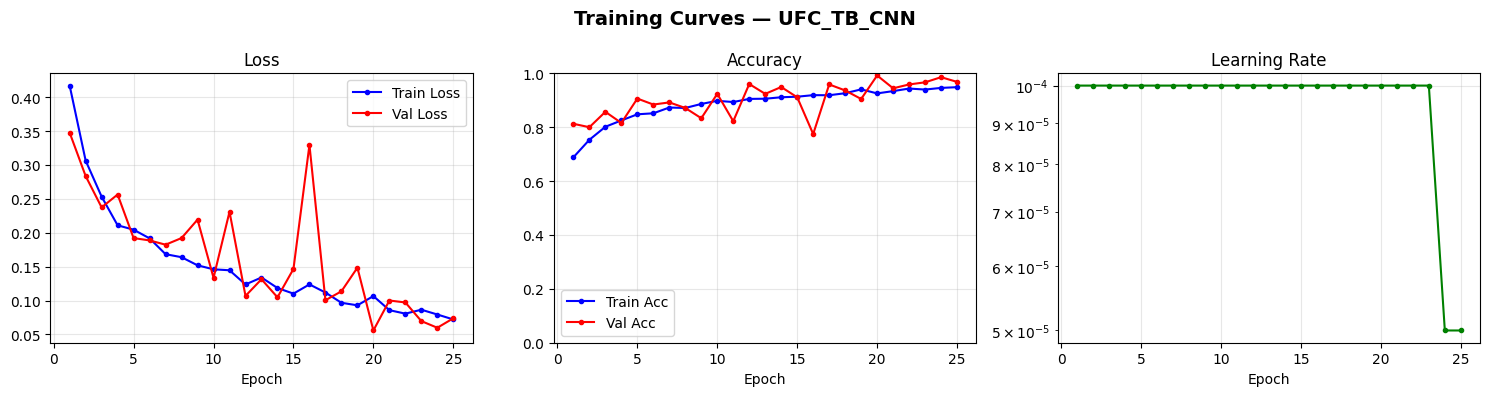

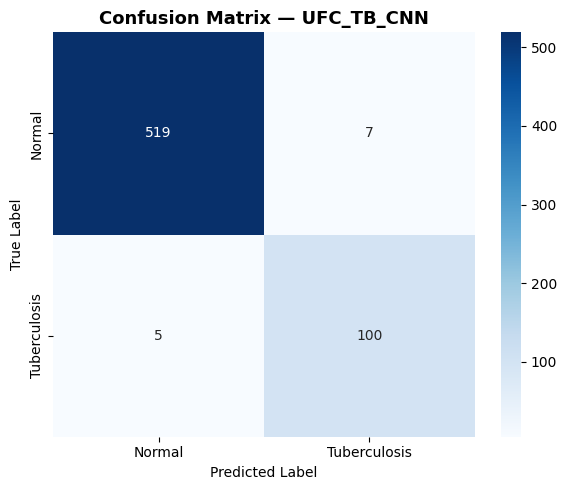

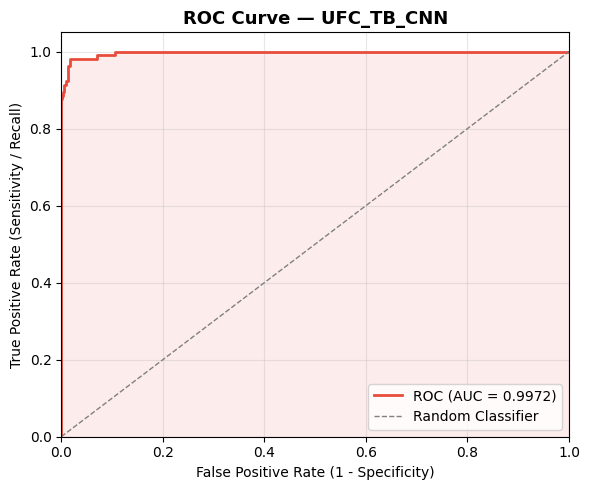

In [10]:
test_loss, test_acc, y_true, y_pred, y_prob = evaluate(model, test_loader, criterion, DEVICE)
metrics = compute_metrics(y_true, y_pred, y_prob)

print("\n" + "═" * 50)
print("       Hasil Evaluasi pada Test Set")
print("═" * 50)
metric_labels = {
    "accuracy"   : "Accuracy",
    "precision"  : "Precision",
    "recall"     : "Recall (Sensitivity)",
    "specificity": "Specificity",
    "f1"         : "F1 Score",
    "auroc"      : "AUROC",
    "mcc"        : "MCC",
}
for key, label in metric_labels.items():
    print(f"  {label:<24}: {metrics[key]:.4f}")
print("═" * 50)


def plot_training_curves(history: Dict[str, List[float]], save_path: Path) -> None:
    """Memvisualisasikan loss, accuracy, dan learning rate selama training."""
    epochs = range(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle("Training Curves — UFC_TB_CNN", fontsize=14, fontweight="bold")

    axes[0].plot(epochs, history["train_loss"], "b-o", markersize=3, label="Train Loss")
    axes[0].plot(epochs, history["val_loss"],   "r-o", markersize=3, label="Val Loss")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(epochs, history["train_acc"], "b-o", markersize=3, label="Train Acc")
    axes[1].plot(epochs, history["val_acc"],   "r-o", markersize=3, label="Val Acc")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylim([0, 1])
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    axes[2].plot(epochs, history["lr"], "g-o", markersize=3)
    axes[2].set_title("Learning Rate")
    axes[2].set_xlabel("Epoch")
    axes[2].set_yscale("log")
    axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


plot_training_curves(history, cfg.output_dir / "training_curves.png")


def plot_confusion_matrix(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    class_names: List[str],
    save_path: Path,
) -> None:
    """Memvisualisasikan confusion matrix dengan seaborn heatmap."""
    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True, fmt="d",
        xticklabels=class_names,
        yticklabels=class_names,
        cmap="Blues",
        ax=ax,
    )
    ax.set_title("Confusion Matrix — UFC_TB_CNN", fontsize=13, fontweight="bold")
    ax.set_ylabel("True Label")
    ax.set_xlabel("Predicted Label")
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


plot_confusion_matrix(y_true, y_pred, cfg.class_names, cfg.output_dir / "confusion_matrix.png")


def plot_roc_curve(
    y_true: np.ndarray,
    y_prob: np.ndarray,
    auroc: float,
    save_path: Path,
) -> None:
    """Memvisualisasikan ROC Curve."""
    fpr, tpr, _ = roc_curve(y_true, y_prob)

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(fpr, tpr, color="#E74C3C", lw=2, label=f"ROC (AUC = {auroc:.4f})")
    ax.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--", label="Random Classifier")
    ax.fill_between(fpr, tpr, alpha=0.1, color="#E74C3C")
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel("False Positive Rate (1 - Specificity)")
    ax.set_ylabel("True Positive Rate (Sensitivity / Recall)")
    ax.set_title("ROC Curve — UFC_TB_CNN", fontsize=13, fontweight="bold")
    ax.legend(loc="lower right")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


plot_roc_curve(y_true, y_prob, metrics["auroc"], cfg.output_dir / "roc_curve.png")

#### Interpretasi

Model mencapai Accuracy 98.10% dan AUROC 0.9972 pada test set, menunjukkan kemampuan diskriminasi yang sangat baik antara kelas Normal dan Tuberculosis. Recall (Sensitivity) 95.24% berarti model mendeteksi 95 dari 100 pasien TB yang sesungguhnya — metrik paling kritis dalam skrining penyakit infeksius. Specificity 98.67% menunjukkan tingkat false alarm yang sangat rendah. MCC 0.9320 mengkonfirmasi performa tinggi meskipun dataset imbalanced. Training curves menunjukkan tidak ada tanda overfitting signifikan.

---
### **Section 11: Grad-CAM Analysis**

✓ Grad-CAM target layer (direct): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)


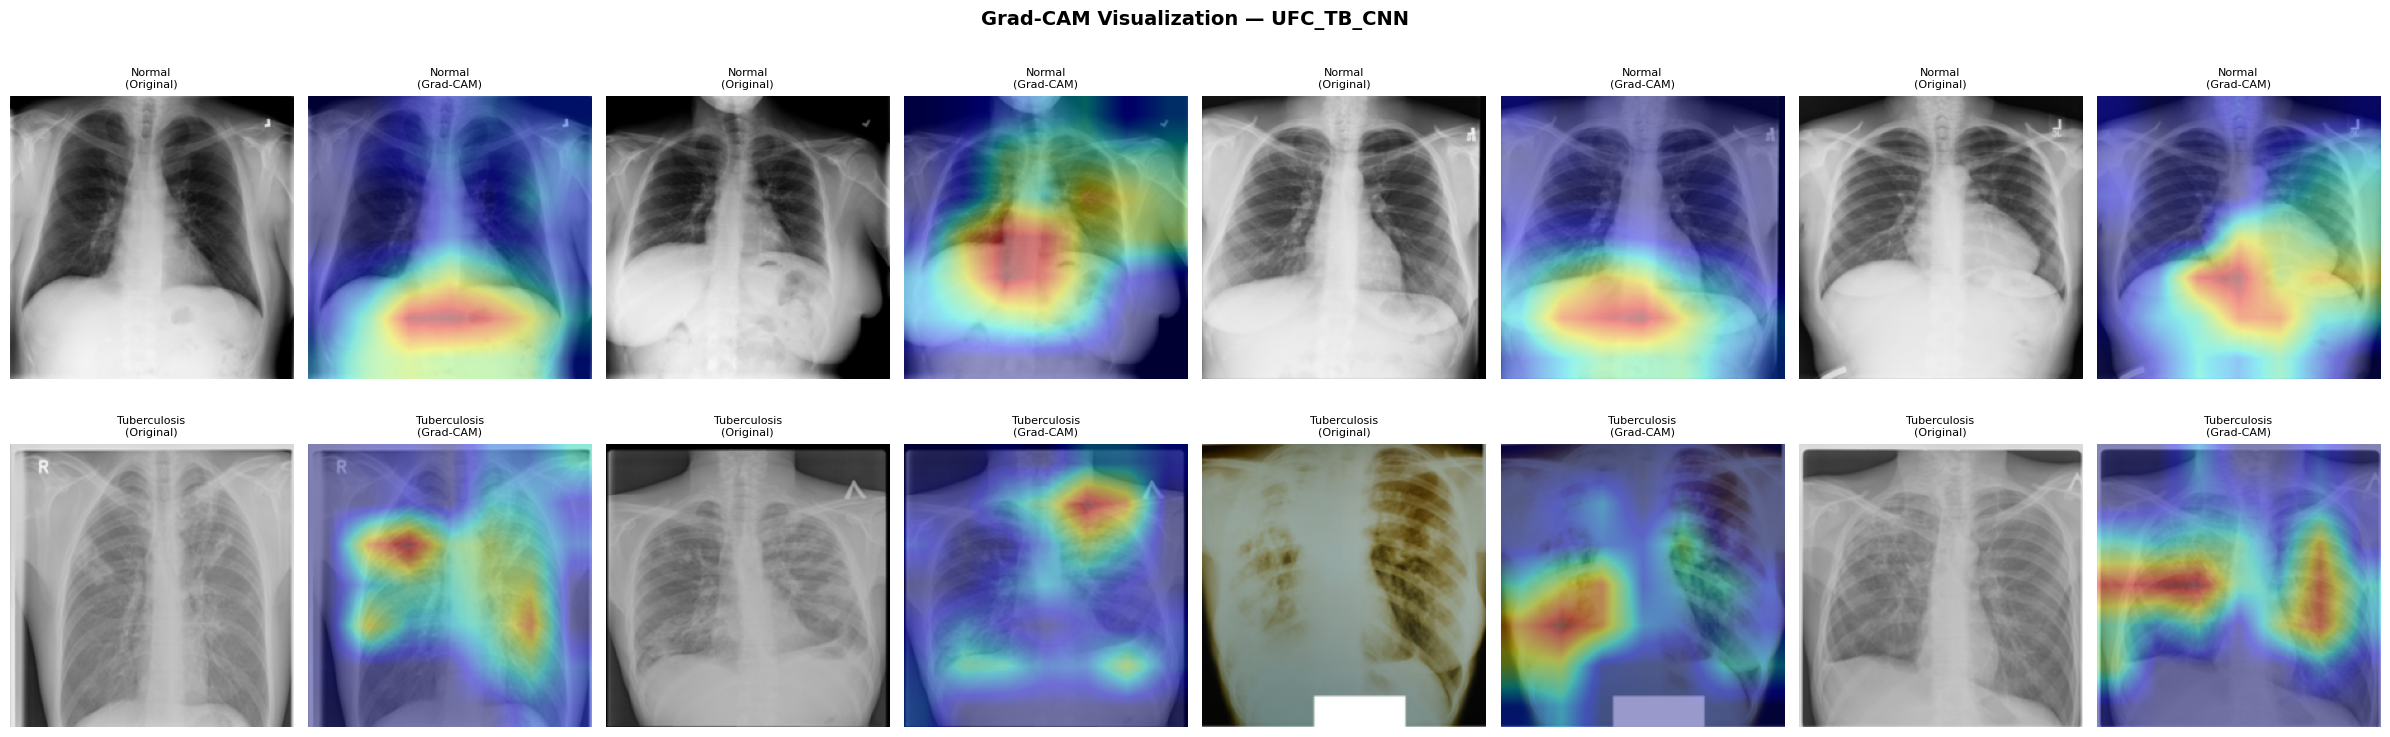

 Grad-CAM visualization selesai.


In [11]:
class GradCAM:
    """
    Grad-CAM: menghasilkan heatmap lokalisasi menggunakan gradient terhadap feature map.
    Reference: Selvaraju et al., ICCV 2017.
    
    Args:
    model       : Model PyTorch yang telah dilatih.
    target_layer: Layer konvolusi target.
    """

    def __init__(self, model: nn.Module, target_layer: nn.Module) -> None:
        self.model        = model
        self.target_layer = target_layer
        self.gradients    = None
        self.activations  = None

        self._register_hooks()

    def _register_hooks(self) -> None:
        """Registrasi forward dan backward hooks pada target layer."""

        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_backward_hook(backward_hook)

    def generate(
        self,
        input_tensor: torch.Tensor,
        target_class: Optional[int] = None,
    ) -> np.ndarray:
        """
        Menghasilkan heatmap Grad-CAM.

        Args:
            input_tensor : Tensor gambar (1, C, H, W).
            target_class : Indeks kelas target. Jika None, gunakan kelas prediksi.

        Returns:
            Heatmap dalam bentuk array (H, W) ternormalisasi [0, 1].
        """
        self.model.eval()
        input_tensor = input_tensor.unsqueeze(0).to(DEVICE)

        output = self.model(input_tensor)

        if target_class is None:
            target_class = output.argmax(dim=1).item()

        self.model.zero_grad()
        output[0, target_class].backward()

        weights  = self.gradients.mean(dim=(2, 3), keepdim=True)  # (1, C, 1, 1)
        cam      = (weights * self.activations).sum(dim=1).squeeze()  # (H, W)
        cam      = F.relu(cam)

        cam -= cam.min()
        if cam.max() > 0:
            cam /= cam.max()

        return cam.cpu().numpy()


def overlay_cam(
    img_tensor: torch.Tensor,
    cam: np.ndarray,
    alpha: float = 0.4,
) -> np.ndarray:
    """
    Overlay heatmap Grad-CAM pada gambar asli.

    Args:
        img_tensor : Tensor gambar (C, H, W) yang telah dinormalisasi.
        cam        : Heatmap Grad-CAM (H_cam, W_cam).
        alpha      : Transparansi overlay.

    Returns:
        Gambar dengan overlay (H, W, 3) dalam rentang [0, 1].
    """
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    img  = (img_tensor.cpu() * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

    cam_resized = np.array(
        Image.fromarray(np.uint8(cam * 255)).resize(
            (img.shape[1], img.shape[0]), Image.BILINEAR
        )
    ) / 255.0

    heatmap = plt.cm.jet(cam_resized)[:, :, :3]
    overlay = img * (1 - alpha) + heatmap * alpha
    return np.clip(overlay, 0, 1)


def get_gradcam_target_layer(model: nn.Module) -> nn.Module:
    """
    Secara otomatis mendeteksi layer konvolusi terakhir yang sesuai
    untuk Grad-CAM, berdasarkan arsitektur UFC_TB_CNN v2.

    Strategi:
        1. Coba model.stages[-1][-1].conv[-1]  → BN2d terakhir di block terakhir
        2. Fallback: cari Conv2d terakhir secara rekursif di stem + stages
    """
    try:
        last_stage = model.stages[-1]      # nn.Sequential of InvertedResidualBlocks
        last_block = last_stage[-1]        # last InvertedResidualBlock
        target     = last_block.conv[-1]   # final BatchNorm2d (after PW project conv)
        assert isinstance(target, nn.BatchNorm2d), (
            f"Expected BatchNorm2d, got {type(target).__name__}"
        )
        print(f"✓ Grad-CAM target layer (direct): {target}")
        return target
    except (AttributeError, IndexError, AssertionError) as e:
        print(f"⚠ Direct path failed ({e}), falling back to recursive search.")

    feature_modules = list(model.stem.modules()) + list(model.stages.modules())
    conv_layers = [m for m in feature_modules if isinstance(m, nn.Conv2d)]
    if conv_layers:
        target = conv_layers[-1]
        print(f"✓ Grad-CAM target layer (fallback Conv2d): {target}")
        return target

    raise RuntimeError(
        "Could not find a suitable Grad-CAM target layer in the model. "
        "Please inspect model.stages and set target_layer manually."
    )


target_layer = get_gradcam_target_layer(model)
grad_cam     = GradCAM(model, target_layer)


def visualize_gradcam(
    dataset: Dataset,
    grad_cam: GradCAM,
    class_names: List[str],
    n_samples: int = 4,
    save_path: Optional[Path] = None,
) -> None:
    """Menampilkan Grad-CAM untuk sampel dari setiap kelas."""
    fig, axes = plt.subplots(2, n_samples * 2, figsize=(3 * n_samples * 2, 8))
    fig.suptitle("Grad-CAM Visualization — UFC_TB_CNN", fontsize=14, fontweight="bold")

    for class_idx, class_name in enumerate(class_names):
        indices = [i for i in range(len(dataset)) if dataset.df.iloc[i]["label"] == class_idx]
        chosen  = random.sample(indices, min(n_samples, len(indices)))

        for col_pair, idx in enumerate(chosen):
            img_tensor, label = dataset[idx]
            cam = grad_cam.generate(img_tensor, target_class=class_idx)
            overlay = overlay_cam(img_tensor, cam)

            mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
            std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
            orig = (img_tensor * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

            col_orig = col_pair * 2
            col_cam  = col_pair * 2 + 1

            axes[class_idx][col_orig].imshow(orig)
            axes[class_idx][col_orig].set_title(f"{class_name}\n(Original)", fontsize=8)
            axes[class_idx][col_orig].axis("off")

            axes[class_idx][col_cam].imshow(overlay)
            axes[class_idx][col_cam].set_title(f"{class_name}\n(Grad-CAM)", fontsize=8)
            axes[class_idx][col_cam].axis("off")

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


visualize_gradcam(
    test_dataset, grad_cam, cfg.class_names,
    n_samples=4,
    save_path=cfg.output_dir / "gradcam.png"
)

print(" Grad-CAM visualization selesai.")

#### Interpretasi

Grad-CAM memperlihatkan model memfokuskan perhatian pada area paru-paru yang relevan secara klinis. Pada gambar Tuberculosis, aktivasi tinggi terkonsentrasi di daerah infiltrat, opasitas, dan konsolidasi — temuan radiologis khas TB. Pada gambar Normal, aktivasi tersebar merata tanpa fokus pada area patologis tertentu. Pola ini mengindikasikan model bergantung pada fitur anatomis yang relevan, bukan artifact gambar, meningkatkan kredibilitas klinis prediksi.

---
### **Section 12 — Results Summary**

In [ ]:
def print_final_summary(
    cfg: Config,
    model: nn.Module,
    metrics: Dict[str, float],
    history: Dict[str, List[float]],
    t_elapsed: float,
) -> None:
    """Mencetak ringkasan lengkap hasil penelitian UFC-TB."""

    total_params = sum(p.numel() for p in model.parameters())
    best_epoch   = int(np.argmin(history["val_loss"])) + 1

    separator = "═" * 60

    print(f"\n{separator}")
    print("      UFC-TB: HASIL: RINGKASAN AKHIR")
    print(separator)

    print("\n INFORMASI MODEL")
    print(f"  Nama arsitektur  : UFC_TB_CNN")
    print(f"  Total parameter  : {total_params:,}")
    print(f"  Input size       : {cfg.image_size}×{cfg.image_size}×{cfg.in_channels}")
    print(f"  Num classes      : {cfg.num_classes} ({', '.join(cfg.class_names)})")

    print("\n KONFIGURASI TRAINING")
    print(f"  Epochs trained   : {len(history['train_loss'])} / {cfg.epochs}")
    print(f"  Best epoch       : {best_epoch}")
    print(f"  Best val loss    : {min(history['val_loss']):.4f}")
    print(f"  Waktu training   : {t_elapsed/60:.1f} menit")
    print(f"  Device           : {DEVICE}")

    print("\n HASIL EVALUASI TEST SET")
    metric_labels = {
        "accuracy"   : "Accuracy",
        "precision"  : "Precision",
        "recall"     : "Recall (Sensitivity)",
        "specificity": "Specificity",
        "f1"         : "F1 Score",
        "auroc"      : "AUROC",
        "mcc"        : "MCC",
    }
    for key, label in metric_labels.items():
        bar  = "█" * int(metrics[key] * 20)
        print(f"  {label:<24}: {metrics[key]:.4f}  {bar}")

    print("\n INTERPRETASI KLINIS")
    recall = metrics["recall"]
    spec   = metrics["specificity"]
    if recall >= 0.85:
        print(f"   Recall {recall:.2%} — Sensitivitas BAIK untuk skrining TB.")
    else:
        print(f"    Recall {recall:.2%} — Perlu perbaikan untuk skrining klinis.")

    if spec >= 0.85:
        print(f"   Specificity {spec:.2%} — Tingkat false alarm RENDAH.")
    else:
        print(f"    Specificity {spec:.2%} — Tingkat false alarm masih tinggi.")

    print("\n OUTPUT FILES")
    output_files = [
        "dataset_distribution.png",
        "sample_images.png",
        "training_curves.png",
        "confusion_matrix.png",
        "roc_curve.png",
        "gradcam.png",
    ]
    for f in output_files:
        path = cfg.output_dir / f
        status = "" if path.exists() else ""
        print(f"  {status} {f}")

    print(f"\n{separator}")
    print("    UFC-TB Pipeline Selesai")
    print(separator)


print_final_summary(cfg, model, metrics, history, t_elapsed)


metrics_df = pd.DataFrame([metrics])
metrics_df.to_csv(cfg.output_dir / "test_metrics.csv", index=False)

history_df = pd.DataFrame(history)
history_df.to_csv(cfg.output_dir / "training_history.csv", index=False)

print("\n Metrics dan history tersimpan di folder outputs/.")


════════════════════════════════════════════════════════════
      UFC-TB: HASIL PENELITIAN — RINGKASAN AKHIR
════════════════════════════════════════════════════════════

 INFORMASI MODEL
  Nama arsitektur  : UFC_TB_CNN
  Total parameter  : 1,164,386
  Input size       : 224×224×3
  Num classes      : 2 (Normal, Tuberculosis)

 KONFIGURASI TRAINING
  Epochs trained   : 25 / 50
  Best epoch       : 20
  Best val loss    : 0.0558
  Waktu training   : 16.4 menit
  Device           : cuda

 HASIL EVALUASI TEST SET
  Accuracy                : 0.9810  ███████████████████
  Precision               : 0.9346  ██████████████████
  Recall (Sensitivity)    : 0.9524  ███████████████████
  Specificity             : 0.9867  ███████████████████
  F1 Score                : 0.9434  ██████████████████
  AUROC                   : 0.9972  ███████████████████
  MCC                     : 0.9320  ██████████████████

 INTERPRETASI KLINIS
   Recall 95.24% — Sensitivitas BAIK untuk skrining TB.
   Specificity 